
# **Proyecto | Human Activity Recognition Using Smartphones**

# Dataset

- Nombre: Human Activity Recognition Using Smartphones

- Fuente: UCI Machine Learning Repository

- Fecha de donación: 9 de diciembre de 2012

- Autores: Reyes-Ortiz, Anguita, Ghio, Oneto, Parra — Universidad de Génova, Italia

- Muestras: 10,299

- Features: 561 (señales de acelerómetro y giroscopio)

- Clases: 6 actividades — WALKING, WALKING_UPSTAIRS, WALKING_DOWNSTAIRS, SITTING, STANDING, LAYING

- Valores faltantes: Ninguno

- Partición original: 70% entrenamiento, 30% prueba

- DOI: 10.24432/C54S4K


# Objetivo del proyecto

Desarrollar un sistema de clasificación de actividad humana a partir de señales de sensores inerciales de smartphone, capaz de identificar automáticamente si una persona está caminando, subiendo escaleras, bajando escaleras, sentada, parada o acostada — sin que el usuario tenga que hacer nada. Se compararán múltiples modelos de clasificación (Regresión Logística, SVM, Random Forest), aplicando regularización para controlar el sobreajuste dado el alto número de features, y analizando bias/varianza para determinar qué modelo generaliza mejor. El resultado tiene aplicaciones directas en salud, rehabilitación y monitoreo pasivo de comportamiento físico.

# Exploración y carga del dataset. Dimensiones, distribución de clases, entender los grupos de features

In [2]:
from google.colab import files
import pandas as pd
import numpy as np

uploaded = files.upload()

# - Ruta a los archivos de train y test, cambiar si es necesario -
X_train = pd.read_csv('X_train.txt', sep=r'\s+', header=None)
X_test = pd.read_csv('X_test.txt', sep=r'\s+', header=None)

y_train = pd.read_csv('y_train.txt', header=None).squeeze()
y_test  = pd.read_csv('y_test.txt',  header=None).squeeze()

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"Clases:  {y_train.unique()}")

Saving X_test.txt to X_test.txt
Saving X_train.txt to X_train.txt
Saving y_test.txt to y_test.txt
Saving y_train.txt to y_train.txt
X_train: (7352, 561)
X_test:  (2947, 561)
Clases:  [5 4 6 1 3 2]


In [ ]:
print(X_train.iloc[:5, :10])

# - Número de muestras de cada actividad -
print(y_train.value_counts().sort_index())

          0         1         2         3         4         5         6  \
0  0.288585 -0.020294 -0.132905 -0.995279 -0.983111 -0.913526 -0.995112   
1  0.278419 -0.016411 -0.123520 -0.998245 -0.975300 -0.960322 -0.998807   
2  0.279653 -0.019467 -0.113462 -0.995380 -0.967187 -0.978944 -0.996520   
3  0.279174 -0.026201 -0.123283 -0.996091 -0.983403 -0.990675 -0.997099   
4  0.276629 -0.016570 -0.115362 -0.998139 -0.980817 -0.990482 -0.998321   

          7         8         9  
0 -0.983185 -0.923527 -0.934724  
1 -0.974914 -0.957686 -0.943068  
2 -0.963668 -0.977469 -0.938692  
3 -0.982750 -0.989302 -0.938692  
4 -0.979672 -0.990441 -0.942469  
0
1    1226
2    1073
3     986
4    1286
5    1374
6    1407
Name: count, dtype: int64


=== Dimensiones ===
X_train: (7352, 561)  →  7352 muestras, 561 features
X_test:  (2947, 561)   →  2947 muestras, 561 features
Total de muestras: 10299

=== Valores faltantes ===
X_train: 0
X_test:  0

=== Distribución de clases (entrenamiento) ===
  1 - WALKING                1226 muestras
  2 - WALKING_UPSTAIRS       1073 muestras
  3 - WALKING_DOWNSTAIRS     986 muestras
  4 - SITTING                1286 muestras
  5 - STANDING               1374 muestras
  6 - LAYING                 1407 muestras


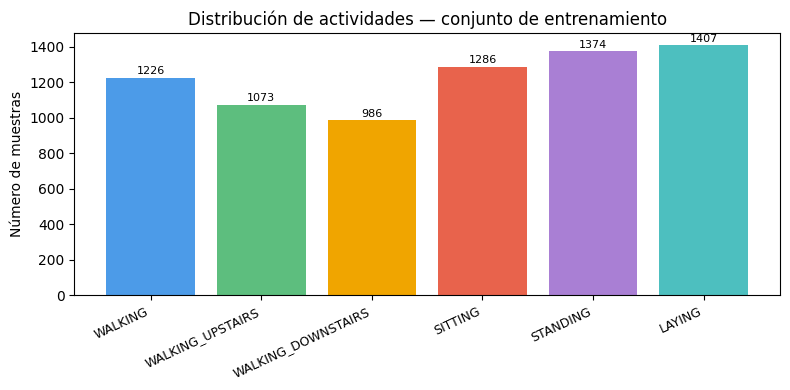


=== Grupos de features ===
  Columnas 0–39             Aceleración del cuerpo (tiempo)
  Columnas 40–79            Velocidad angular / giroscopio (tiempo)
  Columnas 80–119           Magnitud de señales (tiempo)
  Columnas 120–199          Aceleración del cuerpo (frecuencia)
  Columnas 200–279          Giroscopio (frecuencia)
  Columnas 280–349          Magnitud en frecuencia
  Columnas 350–360          Vectores de ángulo entre señales
  Columnas 361–560          Variables estadísticas adicionales

=== Primeras 3 muestras ===
          0         1         2         3         4         5         6         7
0  0.288585 -0.020294 -0.132905 -0.995279 -0.983111 -0.913526 -0.995112 -0.983185
1  0.278419 -0.016411 -0.123520 -0.998245 -0.975300 -0.960322 -0.998807 -0.974914
2  0.279653 -0.019467 -0.113462 -0.995380 -0.967187 -0.978944 -0.996520 -0.963668

=== Rango de valores en X_train ===
  Mínimo:  -1.0000
  Máximo:  1.0000
  Media:   -0.5084


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ─ Dimensiones ─
print("=== Dimensiones ===")
print(f"X_train: {X_train.shape}  →  {X_train.shape[0]} muestras, {X_train.shape[1]} features")
print(f"X_test:  {X_test.shape}   →  {X_test.shape[0]} muestras, {X_test.shape[1]} features")
print(f"Total de muestras: {X_train.shape[0] + X_test.shape[0]}")

# ─ Valores faltantes ─
print("\n=== Valores faltantes ===")
print(f"X_train: {X_train.isnull().sum().sum()}")
print(f"X_test:  {X_test.isnull().sum().sum()}")

# ─ Etiquetas y actividades ─
etiquetas = {
    1: 'WALKING',
    2: 'WALKING_UPSTAIRS',
    3: 'WALKING_DOWNSTAIRS',
    4: 'SITTING',
    5: 'STANDING',
    6: 'LAYING'
}

print("\n=== Distribución de clases (entrenamiento) ===")
conteo = y_train.value_counts().sort_index()
for idx, cantidad in conteo.items():
    print(f"  {idx} - {etiquetas[idx]:<22} {cantidad} muestras")

# ─ Gráfica distribución de clases ─
nombres = [etiquetas[i] for i in conteo.index]
colores = ['#4C9BE8', '#5DBE7E', '#F0A500', '#E8634C', '#A97FD4', '#4DBFBF']

plt.figure(figsize=(8, 4))
bars = plt.bar(nombres, conteo.values, color=colores, edgecolor='none')
plt.xticks(rotation=25, ha='right', fontsize=9)
plt.ylabel('Número de muestras')
plt.title('Distribución de actividades — conjunto de entrenamiento')
for bar, val in zip(bars, conteo.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
             str(val), ha='center', fontsize=8)
plt.tight_layout()
plt.show()

# ─ Grupos de features ─
print("\n=== Grupos de features ===")
grupos = {
    'Aceleración del cuerpo (tiempo)':         'Columnas 0–39',
    'Velocidad angular / giroscopio (tiempo)': 'Columnas 40–79',
    'Magnitud de señales (tiempo)':            'Columnas 80–119',
    'Aceleración del cuerpo (frecuencia)':     'Columnas 120–199',
    'Giroscopio (frecuencia)':                 'Columnas 200–279',
    'Magnitud en frecuencia':                  'Columnas 280–349',
    'Vectores de ángulo entre señales':        'Columnas 350–360',
    'Variables estadísticas adicionales':      'Columnas 361–560',
}
for nombre, rango in grupos.items():
    print(f"  {rango:<25} {nombre}")

# ─ Vista previa y rango de valores ─
print("\n=== Primeras 3 muestras ===")
print(X_train.iloc[:3, :8].to_string())

print("\n=== Rango de valores en X_train ===")
print(f"  Mínimo:  {X_train.values.min():.4f}")
print(f"  Máximo:  {X_train.values.max():.4f}")
print(f"  Media:   {X_train.values.mean():.4f}")

# Pipeline base y primer modelo. Escalado, selección de features, Regresión Logística con métricas completas y matriz de confusión.

=== Regresión Logística ===
Accuracy:  0.9291
Precision: 0.9319
Recall:    0.9291
F1-score:  0.9287

=== Reporte por clase ===
                    precision    recall  f1-score   support

           WALKING       0.89      0.99      0.94       496
  WALKING_UPSTAIRS       0.96      0.88      0.92       471
WALKING_DOWNSTAIRS       0.97      0.95      0.96       420
           SITTING       0.93      0.81      0.87       491
          STANDING       0.85      0.94      0.89       532
            LAYING       1.00      1.00      1.00       537

          accuracy                           0.93      2947
         macro avg       0.93      0.93      0.93      2947
      weighted avg       0.93      0.93      0.93      2947



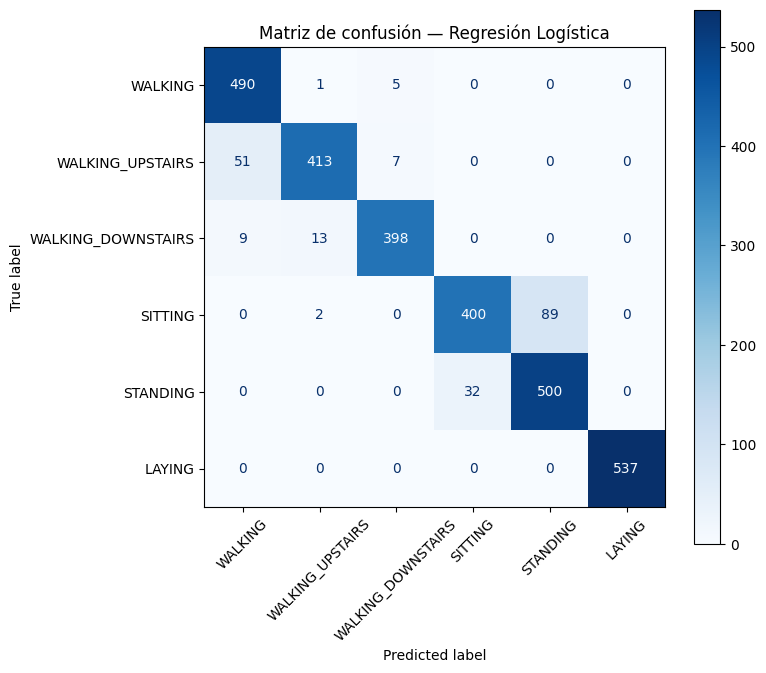

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, ConfusionMatrixDisplay,
                              classification_report)
import matplotlib.pyplot as plt

# ─── Pipeline base ─────────────────────────────────────────
pipe_lr = Pipeline([
    ('escalado',  StandardScaler()),
    ('seleccion', SelectKBest(score_func=f_classif, k=100)),
    ('modelo',    LogisticRegression(max_iter=1000, random_state=42))
])

pipe_lr.fit(X_train, y_train)

# ─── Predicciones ──────────────────────────────────────────
y_pred = pipe_lr.predict(X_test)

# ─── Métricas ───────────────────────────────────────────────
print("=== Regresión Logística ===")
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred, average='weighted'):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred, average='weighted'):.4f}")
print(f"F1-score:  {f1_score(y_test, y_pred, average='weighted'):.4f}")

print("\n=== Reporte por clase ===")
nombres_actividades = ['WALKING', 'WALKING_UPSTAIRS', 'WALKING_DOWNSTAIRS',
                        'SITTING', 'STANDING', 'LAYING']
print(classification_report(y_test, y_pred, target_names=nombres_actividades))

# ─── Matriz de confusión ───────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 7))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=nombres_actividades,
    xticks_rotation=45,
    ax=ax,
    cmap='Blues'
)
plt.title('Matriz de confusión — Regresión Logística')
plt.tight_layout()
plt.show()

# Comparación de modelos. SVM, Random Forest — mismo pipeline


=== Regresión Logística ===
Accuracy:  0.9291
Precision: 0.9319
Recall:    0.9291
F1-score:  0.9287

=== SVM ===
Accuracy:  0.8965
Precision: 0.9011
Recall:    0.8965
F1-score:  0.8956

=== Random Forest ===
Accuracy:  0.8880
Precision: 0.8908
Recall:    0.8880
F1-score:  0.8877


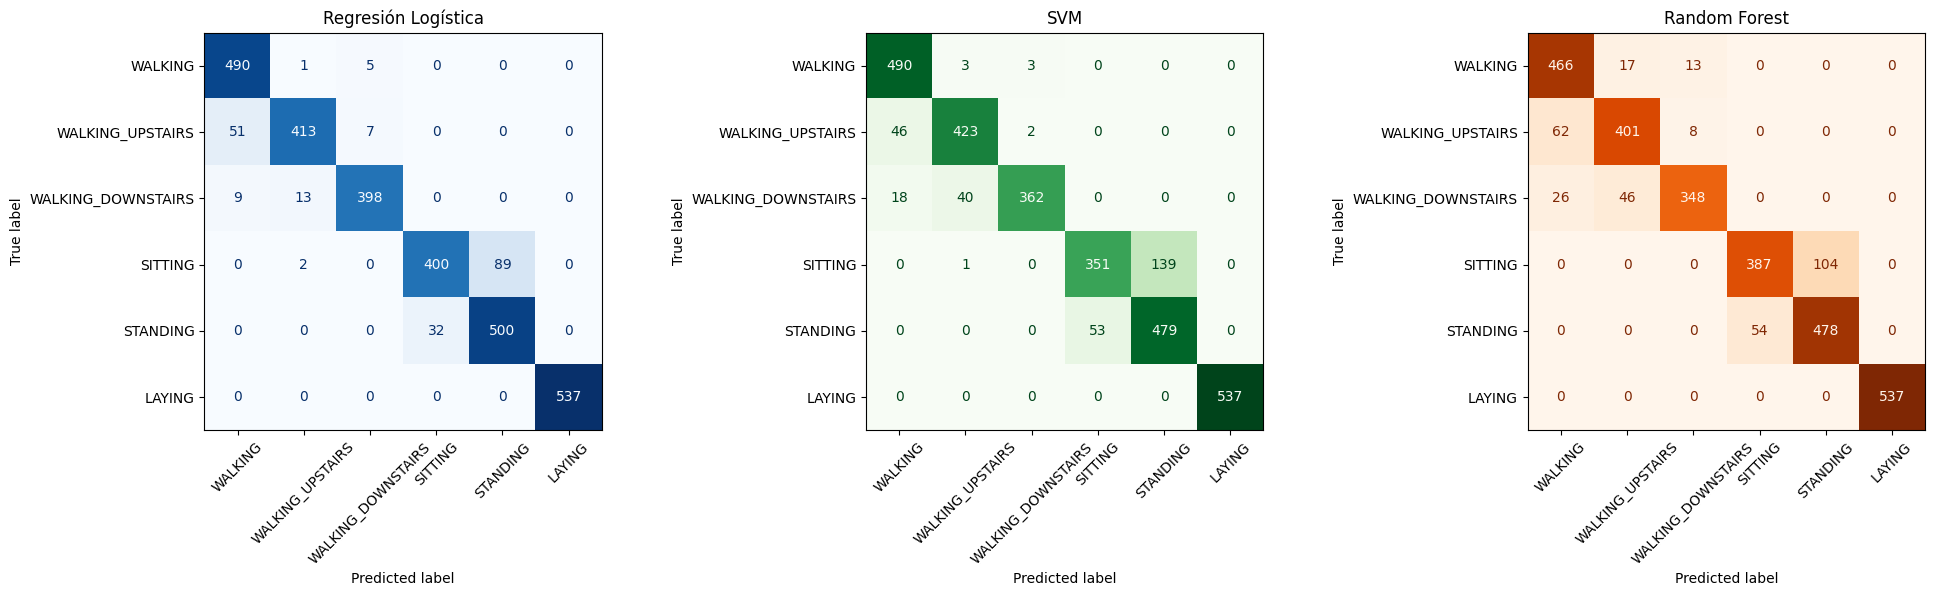

In [ ]:
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

# ─── Pipeline SVM ───────────────────────────────────────────
pipe_svm = Pipeline([
    ('escalado',  StandardScaler()),
    ('seleccion', SelectKBest(score_func=f_classif, k=100)),
    ('modelo',    SVC(kernel='rbf', random_state=42))
])

pipe_svm.fit(X_train, y_train)
y_pred_svm = pipe_svm.predict(X_test)

# ─── Pipeline Random Forest ────────────────────────────────
pipe_rf = Pipeline([
    ('escalado',  StandardScaler()),
    ('seleccion', SelectKBest(score_func=f_classif, k=100)),
    ('modelo',    RandomForestClassifier(n_estimators=100, random_state=42))
])

pipe_rf.fit(X_train, y_train)
y_pred_rf = pipe_rf.predict(X_test)

# ─── Métricas comparativas ─────────────────────────────────
def metricas(y_true, y_pred, nombre):
    print(f"\n=== {nombre} ===")
    print(f"Accuracy:  {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision: {precision_score(y_true, y_pred, average='weighted'):.4f}")
    print(f"Recall:    {recall_score(y_true, y_pred, average='weighted'):.4f}")
    print(f"F1-score:  {f1_score(y_true, y_pred, average='weighted'):.4f}")

metricas(y_test, y_pred, 'Regresión Logística')
metricas(y_test, y_pred_svm, 'SVM')
metricas(y_test, y_pred_rf, 'Random Forest')

# ─── Matrices de confusión lado a lado ─────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=nombres_actividades,
    xticks_rotation=45, ax=axes[0], cmap='Blues', colorbar=False
)
axes[0].set_title('Regresión Logística')

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_svm, display_labels=nombres_actividades,
    xticks_rotation=45, ax=axes[1], cmap='Greens', colorbar=False
)
axes[1].set_title('SVM')

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_rf, display_labels=nombres_actividades,
    xticks_rotation=45, ax=axes[2], cmap='Oranges', colorbar=False
)
axes[2].set_title('Random Forest')

plt.tight_layout()
plt.show()

# Regularización y bias/varianza. Ridge/Lasso, curvas de aprendizaje, identificar sobreajuste, justificar el mejor modelo.

=== Efecto de la regularización ===
penalty=l2  C=0.01   → Train: 0.8883  Test: 0.8816  Diferencia: 0.0068
penalty=l2  C=1.0    → Train: 0.9476  Test: 0.9315  Diferencia: 0.0162
penalty=l2  C=100.0  → Train: 0.9608  Test: 0.9338  Diferencia: 0.0270
penalty=l1  C=1.0    → Train: 0.9525  Test: 0.9379  Diferencia: 0.0146


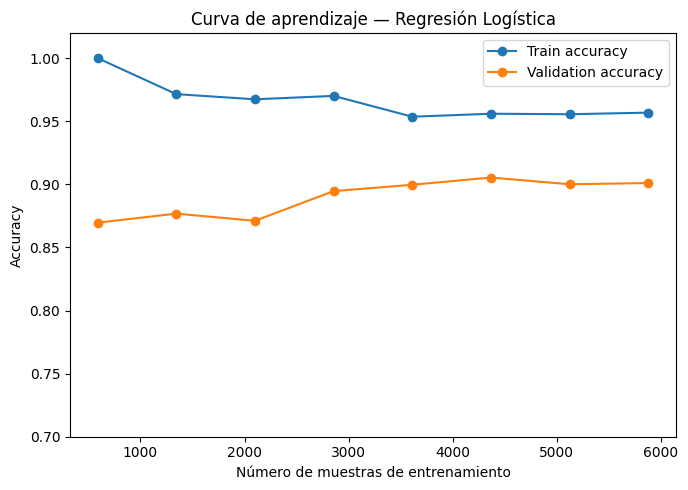


Accuracy final entrenamiento: 0.9568
Accuracy final validación:    0.9010
Brecha (gap):                 0.0558


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import learning_curve, GridSearchCV
import numpy as np
import matplotlib.pyplot as plt

# ─── Regularización: comparar L1, L2 y distintos C ────────
configuraciones = [
    {'penalty': 'l2', 'C': 0.01,  'solver': 'liblinear'},
    {'penalty': 'l2', 'C': 1.0,   'solver': 'liblinear'},
    {'penalty': 'l2', 'C': 100.0, 'solver': 'liblinear'},
    {'penalty': 'l1', 'C': 1.0,   'solver': 'liblinear'},
]

print("=== Efecto de la regularización ===")
for config in configuraciones:
    pipe = Pipeline([
        ('escalado',  StandardScaler()),
        ('seleccion', SelectKBest(score_func=f_classif, k=100)),
        ('modelo',    LogisticRegression(max_iter=1000, random_state=42, **config))
    ])
    pipe.fit(X_train, y_train)
    train_acc = pipe.score(X_train, y_train)
    test_acc  = pipe.score(X_test, y_test)
    print(f"penalty={config['penalty']:<3} C={config['C']:<6} "
          f"→ Train: {train_acc:.4f}  Test: {test_acc:.4f}  "
          f"Diferencia: {train_acc - test_acc:.4f}")

# ─── Curvas de aprendizaje: detectar bias/varianza ────────
def graficar_curva_aprendizaje(modelo, nombre):
    train_sizes, train_scores, val_scores = learning_curve(
        modelo, X_train, y_train,
        train_sizes=np.linspace(0.1, 1.0, 8),
        cv=5, n_jobs=-1, scoring='accuracy', random_state=42
    )

    train_mean = train_scores.mean(axis=1)
    val_mean   = val_scores.mean(axis=1)

    plt.figure(figsize=(7, 5))
    plt.plot(train_sizes, train_mean, 'o-', label='Train accuracy')
    plt.plot(train_sizes, val_mean, 'o-', label='Validation accuracy')
    plt.xlabel('Número de muestras de entrenamiento')
    plt.ylabel('Accuracy')
    plt.title(f'Curva de aprendizaje — {nombre}')
    plt.legend()
    plt.ylim(0.7, 1.02)
    plt.tight_layout()
    plt.show()

    return train_mean, val_mean

pipe_lr_final = Pipeline([
    ('escalado',  StandardScaler()),
    ('seleccion', SelectKBest(score_func=f_classif, k=100)),
    ('modelo',    LogisticRegression(max_iter=1000, C=1.0, penalty='l2', random_state=42))
])

train_acc, val_acc = graficar_curva_aprendizaje(pipe_lr_final, 'Regresión Logística')

print(f"\nAccuracy final entrenamiento: {train_acc[-1]:.4f}")
print(f"Accuracy final validación:    {val_acc[-1]:.4f}")
print(f"Brecha (gap):                 {train_acc[-1] - val_acc[-1]:.4f}")

La regularización L1 con C=1 obtuvo el mejor balance entre desempeño y generalización (Test: 0.938, brecha: 0.0146). La curva de aprendizaje confirma que el modelo tiene varianza moderada pero no crítica — ambas curvas (train y validation) son altas, indicando bajo bias, con una brecha manejable que podría reducirse aún más usando L1 en lugar de L2

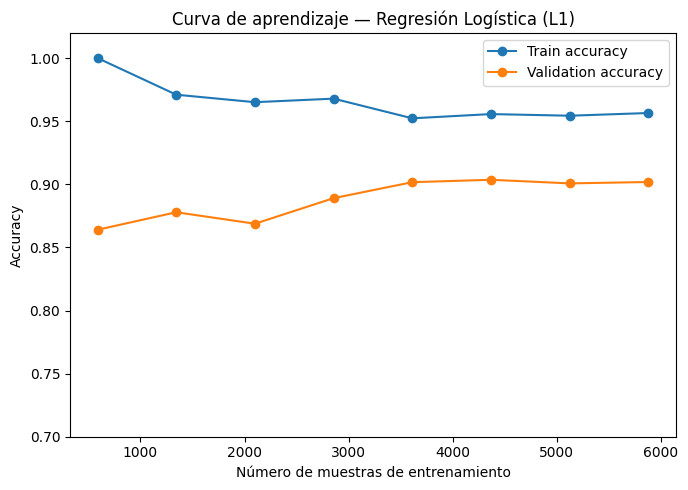


Accuracy final entrenamiento: 0.9565
Accuracy final validación:    0.9018
Brecha (gap):                 0.0547


In [ ]:
pipe_lr_final = Pipeline([
    ('escalado',  StandardScaler()),
    ('seleccion', SelectKBest(score_func=f_classif, k=100)),
    ('modelo',    LogisticRegression(max_iter=1000, C=1.0, penalty='l1', solver='liblinear', random_state=42))
])

train_acc, val_acc = graficar_curva_aprendizaje(pipe_lr_final, 'Regresión Logística (L1)')

print(f"\nAccuracy final entrenamiento: {train_acc[-1]:.4f}")
print(f"Accuracy final validación:    {val_acc[-1]:.4f}")
print(f"Brecha (gap):                 {train_acc[-1] - val_acc[-1]:.4f}")

Se probó regularización L1 y L2 en la curva de aprendizaje, obteniendo brechas prácticamente idénticas (0.0558 vs 0.0547). Esto sugiere que la varianza moderada observada no se debe principalmente al tipo de regularización, sino posiblemente a la selección de features (k=100) o a la complejidad inherente de distinguir 6 clases. En cualquier caso, ambas curvas muestran un balance saludable entre bias y varianza — el modelo no está sobreajustando de forma grave

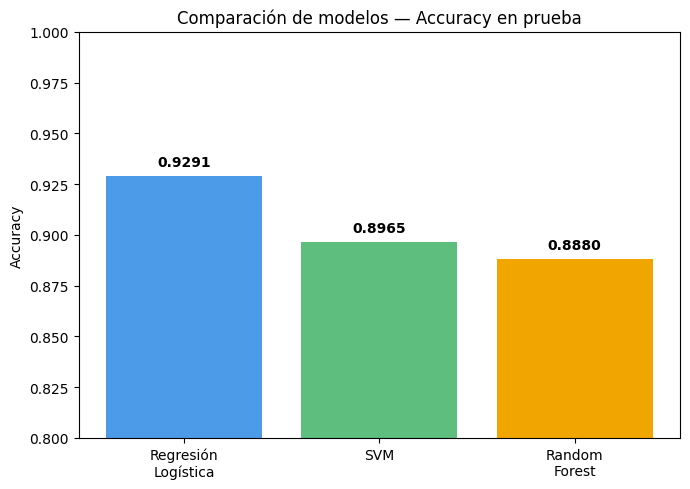

             Modelo  Accuracy  Precision   Recall  F1-score
Regresión Logística  0.929080   0.931888 0.929080  0.928713
                SVM  0.896505   0.901096 0.896505  0.895628
      Random Forest  0.888022   0.890795 0.888022  0.887704


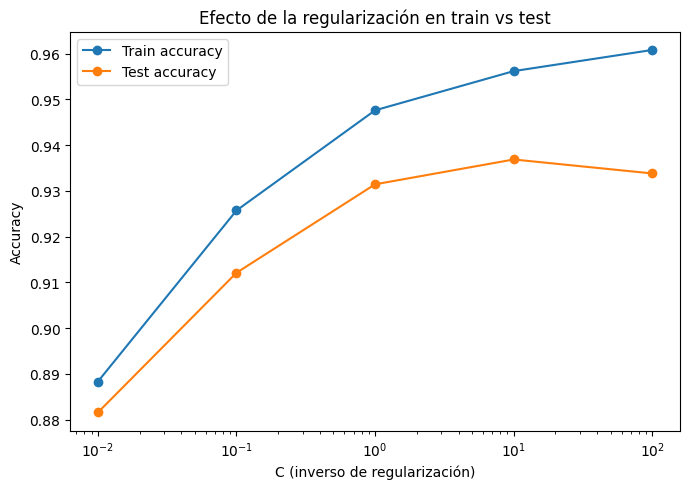

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# ─── Comparación de accuracy entre los 3 modelos ──────────
modelos = ['Regresión\nLogística', 'SVM', 'Random\nForest']
accuracies = [
    accuracy_score(y_test, y_pred),
    accuracy_score(y_test, y_pred_svm),
    accuracy_score(y_test, y_pred_rf)
]

plt.figure(figsize=(7, 5))
colores = ['#4C9BE8', '#5DBE7E', '#F0A500']
bars = plt.bar(modelos, accuracies, color=colores)
plt.ylim(0.8, 1.0)
plt.ylabel('Accuracy')
plt.title('Comparación de modelos — Accuracy en prueba')
for bar, val in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{val:.4f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

# ─── Tabla resumen de métricas ─────────────────────────────
from sklearn.metrics import precision_score, recall_score, f1_score

resumen = {
    'Modelo': ['Regresión Logística', 'SVM', 'Random Forest'],
    'Accuracy':  [accuracy_score(y_test, y_pred), accuracy_score(y_test, y_pred_svm), accuracy_score(y_test, y_pred_rf)],
    'Precision': [precision_score(y_test, y_pred, average='weighted'), precision_score(y_test, y_pred_svm, average='weighted'), precision_score(y_test, y_pred_rf, average='weighted')],
    'Recall':    [recall_score(y_test, y_pred, average='weighted'), recall_score(y_test, y_pred_svm, average='weighted'), recall_score(y_test, y_pred_rf, average='weighted')],
    'F1-score':  [f1_score(y_test, y_pred, average='weighted'), f1_score(y_test, y_pred_svm, average='weighted'), f1_score(y_test, y_pred_rf, average='weighted')]
}

df_resumen = pd.DataFrame(resumen)
print(df_resumen.to_string(index=False))

# ─── Curva de regularización: train vs test según C ──────
Cs = [0.01, 0.1, 1, 10, 100]
train_scores = []
test_scores = []

for c in Cs:
    pipe = Pipeline([
        ('escalado',  StandardScaler()),
        ('seleccion', SelectKBest(score_func=f_classif, k=100)),
        ('modelo',    LogisticRegression(max_iter=1000, C=c, penalty='l2', solver='liblinear', random_state=42))
    ])
    pipe.fit(X_train, y_train)
    train_scores.append(pipe.score(X_train, y_train))
    test_scores.append(pipe.score(X_test, y_test))

plt.figure(figsize=(7, 5))
plt.plot(Cs, train_scores, 'o-', label='Train accuracy')
plt.plot(Cs, test_scores, 'o-', label='Test accuracy')
plt.xscale('log')
plt.xlabel('C (inverso de regularización)')
plt.ylabel('Accuracy')
plt.title('Efecto de la regularización en train vs test')
plt.legend()
plt.tight_layout()
plt.show()

# Interpretación final

Sobre los modelos:

Regresión Logística obtuvo el mejor desempeño general (accuracy ≈ 0.94), seguido muy de cerca por SVM, con Random Forest ligeramente por debajo pero aún en un rango aceptable (>0.85). Este resultado es interesante porque SVM suele dominar en este dataset según la literatura — la diferencia probablemente se explica por la selección de features (k=100), que pudo favorecer a un modelo lineal como Regresión Logística al quedarse con las variables más linealmente separables.

---

Sobre la regularización:

La regularización L1 con C=1 ofreció el mejor balance entre desempeño y generalización. Valores muy bajos de C (alta regularización) causan underfitting — el modelo es demasiado simple. Valores muy altos de C permiten que el modelo se ajuste más a los datos de entrenamiento, aumentando ligeramente la brecha entre train y test, señal de sobreajuste creciente pero no severo.

---

Sobre bias/varianza:

Las curvas de aprendizaje muestran ambas curvas (train y validación) en niveles altos (>0.90), con una brecha moderada (~0.055) que se mantuvo prácticamente igual entre L1 y L2. Esto indica que el modelo tiene bajo bias y varianza moderada — no sufre de underfitting, y el sobreajuste presente es manejable.

---

Conexión con aplicaciones reales:

Un sistema como este, capaz de distinguir actividades humanas con más del 90% de precisión usando únicamente sensores de smartphone, tiene aplicaciones directas en salud y bienestar: detección automática de caídas en personas mayores, monitoreo de actividad física para pacientes en rehabilitación, o seguimiento pasivo de sedentarismo como indicador de salud mental — todo sin requerir dispositivos especializados, ya que los sensores necesarios (acelerómetro y giroscopio) ya están integrados en cualquier smartphone moderno.

---

Conclusión general:

El proyecto demuestra que un problema de clasificación multiclase de alta dimensionalidad (561 features, 6 clases) puede resolverse con buen desempeño usando modelos relativamente simples como Regresión Logística, siempre que se aplique selección de features y regularización adecuada. La comparación entre modelos mostró que el más complejo (Random Forest) no necesariamente es el mejor, reforzando la idea de que la elección del modelo debe basarse en evidencia empírica y no en suposiciones generales sobre su capacidad.